In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Reading in Data and establishing Multi Indices

In [2]:
leftQuenchMaxBound = 0.94
rightQuenchMaxBound = 0.82
md = pd.read_excel("251006 Add 9_0 Data.xlsx")
samplesAndBlank = md.columns.tolist()[2:]
samples = samplesAndBlank[1:]  # Exclude the first three columns which are not samples
md_multi = md.set_index('foldTrial') 
data = md_multi.pivot(columns='fluor', values=samplesAndBlank)
data.head()

Blank                   0_0 L                        5_0           \
fluor        A488     Cy3    Cy5     A488      Cy3      Cy5     A488      Cy3   
foldTrial                                                                       
1          1993.0  1638.0  377.0  42299.0  43800.0  45511.0  40773.0  41043.0   
2          2272.0  1726.0  370.0  42764.0  42223.0  44110.0  42768.0  41663.0   
3          1973.0  1619.0  355.0  43040.0  41717.0  43293.0  44200.0  40386.0   

                        6_0  ...     0_10     0_11                       0_12  \
fluor          Cy5     A488  ...      Cy5     A488      Cy3      Cy5     A488   
foldTrial                    ...                                                
1          36567.0  41844.0  ...  40479.0  42173.0  21533.0  39618.0  40346.0   
2          39029.0  43137.0  ...  40715.0  41405.0  20696.0  39912.0  44131.0   
3          37421.0  42442.0  ...  42365.0  43930.0  21590.0  42057.0  44209.0   

                                0_15                    
fluor          Cy3      Cy5     A488      Cy3      Cy5  
foldTrial                                               
1          21023.0  39213.0  41726.0  22199.0  40143.0  
2          21495.0  42215.0  42648.0  21310.0  41333.0  
3          21115.0  41877.0  43384.0  22109.0  41140.0  

[3 rows x 63 columns]

## Subtracting Average Blank by fluorophore

In [3]:
idx = pd.IndexSlice
fluors = ['A488', 'Cy3', 'Cy5']
blankData = data.loc[:, idx[samples, :]]
for fluor in fluors:
    avgBlank = data.loc[:, idx[['Blank'], fluor]].mean(axis=None)
    blankData.loc[:, idx[:, fluor]] -= avgBlank
    # print(fluor)
blankData.head()

0_0 L                                  5_0           \
fluor              A488      Cy3           Cy5          A488      Cy3   
foldTrial                                                               
1          40219.666667  42139.0  45143.666667  38693.666667  39382.0   
2          40684.666667  40562.0  43742.666667  40688.666667  40002.0   
3          40960.666667  40056.0  42925.666667  42120.666667  38725.0   

                                  6_0                                  7_0  \
fluor               Cy5          A488      Cy3           Cy5          A488   
foldTrial                                                                    
1          36199.666667  39764.666667  39930.0  30716.666667  40589.666667   
2          38661.666667  41057.666667  39291.0  30519.666667  42060.666667   
3          37053.666667  40362.666667  37640.0  29155.666667  42969.666667   

           ...          0_10          0_11                         \
fluor      ...           Cy5          A488      Cy3           Cy5   
foldTrial  ...                                                      
1          ...  40111.666667  40093.666667  19872.0  39250.666667   
2          ...  40347.666667  39325.666667  19035.0  39544.666667   
3          ...  41997.666667  41850.666667  19929.0  41689.666667   

                   0_12                                 0_15           \
fluor              A488      Cy3           Cy5          A488      Cy3   
foldTrial                                                               
1          38266.666667  19362.0  38845.666667  39646.666667  20538.0   
2          42051.666667  19834.0  41847.666667  40568.666667  19649.0   
3          42129.666667  19454.0  41509.666667  41304.666667  20448.0   

                         
fluor               Cy5  
foldTrial                
1          39775.666667  
2          40965.666667  
3          40772.666667  

[3 rows x 60 columns]

## Creating Normalized Cy Fluor Columns

In [4]:
normdata = blankData.copy()
for sample in samples:
    normdata[(sample, 'Cy3/A488')] = normdata[(sample, 'Cy3')] / normdata[(sample, 'A488')]
    normdata[(sample, 'Cy5/A488')] = normdata[(sample, 'Cy5')] / normdata[(sample, 'A488')]
    normdata[(sample, 'Cy3/Cy5')] = normdata[(sample, 'Cy3')] / normdata[(sample, 'Cy5')]
    normdata[(sample, 'Cy5/Cy3')] = normdata[(sample, 'Cy5')] / normdata[(sample, 'Cy3')]
# Reorder columns for readability
normdata = normdata.reindex(
    columns=pd.MultiIndex.from_product(
        [ samples, ['A488', 'Cy3', 'Cy5', 'Cy3/A488', 'Cy5/A488', 'Cy3/Cy5', 'Cy5/Cy3'] ]
    ),
    fill_value=np.nan
)
normdata

0_0 L                                                       \
                   A488      Cy3           Cy5  Cy3/A488  Cy5/A488   Cy3/Cy5   
foldTrial                                                                      
1          40219.666667  42139.0  45143.666667  1.047721  1.122428  0.933442   
2          40684.666667  40562.0  43742.666667  0.996985  1.075163  0.927287   
3          40960.666667  40056.0  42925.666667  0.977914  1.047973  0.933148   

                              5_0                         ...      0_12  \
            Cy5/Cy3          A488      Cy3           Cy5  ...  Cy5/A488   
foldTrial                                                 ...             
1          1.071304  38693.666667  39382.0  36199.666667  ...  1.015131   
2          1.078415  40688.666667  40002.0  38661.666667  ...  0.995149   
3          1.071641  42120.666667  38725.0  37053.666667  ...  0.985284   

                                       0_15                                   \
            Cy3/Cy5   Cy5/Cy3          A488      Cy3           Cy5  Cy3/A488   
foldTrial                                                                      
1          0.498434  2.006284  39646.666667  20538.0  39775.666667  0.518026   
2          0.473957  2.109895  40568.666667  19649.0  40965.666667  0.484339   
3          0.468662  2.133734  41304.666667  20448.0  40772.666667  0.495053   

                                         
           Cy5/A488   Cy3/Cy5   Cy5/Cy3  
foldTrial                                
1          1.003254  0.516346  1.936686  
2          1.009786  0.479646  2.084873  
3          0.987120  0.501512  1.993968  

[3 rows x 140 columns]

## Creating Scaled Cy Fluor Columns
This will scale the fluorescence plots so that 1 is max fluorescence and the minimum fluorescence is 1 minus the max fraction bound from TEM analysis

In [5]:
scaledata = normdata.copy()
minLeftFluor = 1-leftQuenchMaxBound
minRightFluor = 1-rightQuenchMaxBound
rightMinA488 = scaledata.loc[:, idx['0_15', 'Cy3/A488']].mean()
leftMinA488 = scaledata.loc[:, idx['15_0', 'Cy5/A488']].mean()
rightMaxA488 = scaledata.loc[:, idx['0_0 R', 'Cy3/A488']].mean()
leftMaxA488 = scaledata.loc[:, idx['0_0 L', 'Cy5/A488']].mean()

rightMinCy = scaledata.loc[:, idx['0_15', 'Cy3/Cy5']].mean()
leftMinCy = scaledata.loc[:, idx['15_0', 'Cy5/Cy3']].mean()
rightMaxCy = scaledata.loc[:, idx['0_0 R', 'Cy3/Cy5']].mean()
leftMaxCy = scaledata.loc[:, idx['0_0 L', 'Cy5/Cy3']].mean()
scaledata = normdata.copy()
minLeftFluor = 1-leftQuenchMaxBound
minRightFluor = 1-rightQuenchMaxBound
for sample in samples:
    scaledata[(sample, 'Cy3/A488')] = minRightFluor + (scaledata[(sample, 'Cy3/A488')] - rightMinA488) * (1 - minRightFluor) / (rightMaxA488 - rightMinA488)
    scaledata[(sample, 'Cy5/A488')] = minLeftFluor + (scaledata[(sample, 'Cy5/A488')] - leftMinA488) * (1 - minLeftFluor) / (leftMaxA488 - leftMinA488)
    scaledata[(sample, 'Cy3/Cy5')] = minRightFluor + (scaledata[(sample, 'Cy3/Cy5')] - rightMinCy) * (1 - minRightFluor) / (rightMaxCy - rightMinCy)
    scaledata[(sample, 'Cy5/Cy3')] = minLeftFluor + (scaledata[(sample, 'Cy5/Cy3')] - leftMinCy) * (1 - minLeftFluor) / (leftMaxCy - leftMinCy)
# Reorder columns for readability
scaledata = scaledata.reindex(
    columns=pd.MultiIndex.from_product(
        [ samples, ['A488', 'Cy3', 'Cy5', 'Cy3/A488', 'Cy5/A488', 'Cy3/Cy5', 'Cy5/Cy3'] ]
    ),
    fill_value=np.nan
)
scaledata

0_0 L                                                       \
                   A488      Cy3           Cy5  Cy3/A488  Cy5/A488   Cy3/Cy5   
foldTrial                                                                      
1          40219.666667  42139.0  45143.666667  1.122986  1.044239  0.930968   
2          40684.666667  40562.0  43742.666667  1.035773  0.992704  0.920324   
3          40960.666667  40056.0  42925.666667  1.002990  0.963056  0.930459   

                              5_0                         ...      0_12  \
            Cy5/Cy3          A488      Cy3           Cy5  ...  Cy5/A488   
foldTrial                                                 ...             
1          0.997332  38693.666667  39382.0  36199.666667  ...  0.927246   
2          1.004974  40688.666667  40002.0  38661.666667  ...  0.905459   
3          0.997694  42120.666667  38725.0  37053.666667  ...  0.894702   

                                       0_15                                   \
            Cy3/Cy5   Cy5/Cy3          A488      Cy3           Cy5  Cy3/A488   
foldTrial                                                                      
1          0.178731  2.002159  39646.666667  20538.0  39775.666667  0.212465   
2          0.136404  2.113511  40568.666667  19649.0  40965.666667  0.154559   
3          0.127248  2.139131  41304.666667  20448.0  40772.666667  0.172976   

                                         
           Cy5/A488   Cy3/Cy5   Cy5/Cy3  
foldTrial                                
1          0.914296  0.209705  1.927363  
2          0.921419  0.146241  2.086620  
3          0.896705  0.184054  1.988924  

[3 rows x 140 columns]

## Plotting

### Cy Scaling

In [6]:
leftTEMbp = [6, 7, 8, 15]
leftTEM = [0.53, 0.52, 0.69, 0.94]
rightTEMbp = [6, 7, 15]
rightTEM = [0.33, 0.48, 0.82]

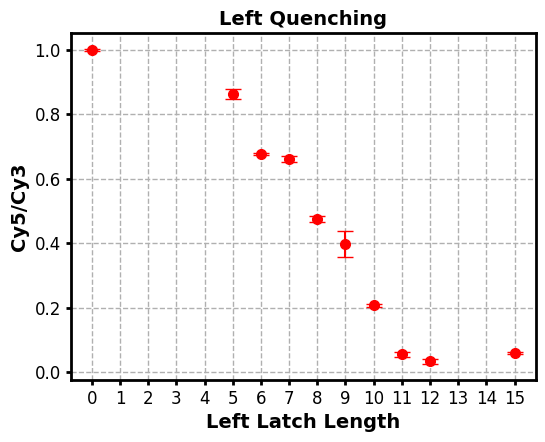

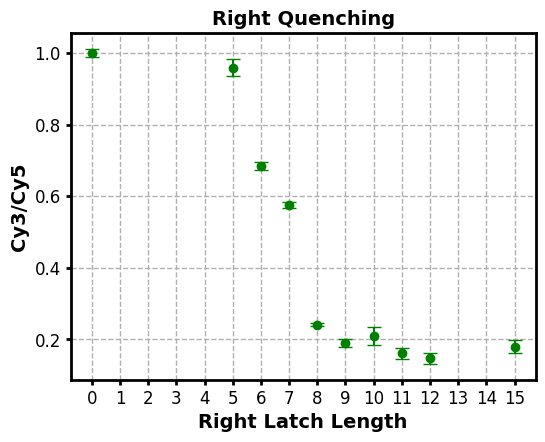

In [7]:
leftSamples = samples[:10]
rightSamples = samples[10:]
# print(leftSamples, rightSamples)
leftfig, axleft = plt.subplots(figsize=(6, 4.5))
rightfig, axright = plt.subplots(figsize=(6, 4.5))
for sample in leftSamples:
    axleft.errorbar(int(sample.split('_')[0]), scaledata[(sample, 'Cy5/Cy3')].mean(), 
                yerr=scaledata[(sample, 'Cy5/Cy3')].sem(), label=f'Cy5/Cy3 {sample}', fmt='ro', markersize=7, capsize=6)
axleft.set_title('Left Quenching', fontsize=14, fontweight='bold')
axleft.set_xlabel('Left Latch Length', fontsize=14, fontweight='bold')
axleft.set_ylabel('Cy5/Cy3', fontsize=14, fontweight='bold')
for sample in rightSamples:
    axright.errorbar(int(sample.split('_')[1].split()[0]), scaledata[(sample, 'Cy3/Cy5')].mean(), 
                yerr=scaledata[(sample, 'Cy3/Cy5')].sem(), label=f'Cy3/Cy5 {sample}', fmt='go', capsize=5)
# axright.plot(rightTEMbp, rightTEM, 'ko', label=f'TEM')
axright.set_title('Right Quenching', fontsize=14, fontweight='bold')
axright.set_xlabel('Right Latch Length', fontsize=14, fontweight='bold')
axright.set_ylabel('Cy3/Cy5', fontsize=14, fontweight='bold')
for ax1 in [axleft, axright]:
    ax1.grid(True, which='both', linestyle='--', linewidth=1)
    ax1.tick_params(axis='both', which='both', width=2, labelsize=12)
    ax1.set_xticks(list(range(16)))
    ax1.spines['left'].set_linewidth(2)
    ax1.spines['bottom'].set_linewidth(2)
    ax1.spines['right'].set_linewidth(2)
    ax1.spines['top'].set_linewidth(2)
leftfig.savefig('left_cyScaled.png', bbox_inches='tight', dpi=300)
rightfig.savefig('right_cyScaled.png', bbox_inches='tight', dpi=300)

## Flip plot to quenching, add TEM

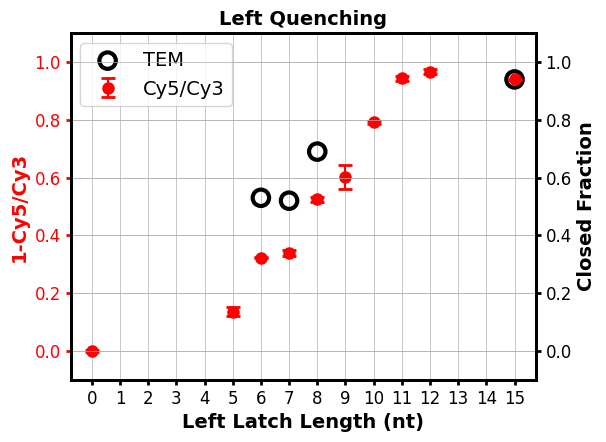

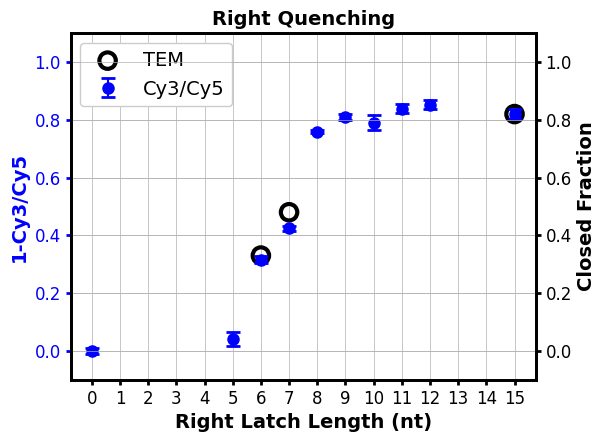

In [11]:
leftSamples = samples[:10]
rightSamples = samples[10:]
# print(leftSamples, rightSamples)
leftfig, axleft = plt.subplots(figsize=(6, 4.5))
rightfig, axright = plt.subplots(figsize=(6, 4.5))

for sample in leftSamples:
    axleft.errorbar(int(sample.split('_')[0]), 1-scaledata[(sample, 'Cy5/Cy3')].mean(), 
                yerr=scaledata[(sample, 'Cy5/Cy3')].sem(), label=f'Cy5/Cy3' if sample==leftSamples[0] else '', fmt='ro', markersize=8, capsize=5, capthick=2)
axleft.scatter(leftTEMbp, leftTEM, facecolors='none', edgecolors='k', linewidth=3, s=140, label=f'TEM')
axleft.set_title('Left Quenching', fontsize=14, fontweight='bold')
axleft.set_xlabel('Left Latch Length (nt)', fontsize=14, fontweight='bold')
axleft.tick_params(axis='y', color='red', labelcolor='red')
axleft.set_ylabel('1-Cy5/Cy3', fontsize=14, fontweight='bold', color='red')
axalleftalleft = axleft.twinx()
axalleftalleft.set_ylabel('Closed Fraction', fontsize=14, fontweight='bold')



for sample in rightSamples:
    axright.errorbar(int(sample.split('_')[1].split()[0]), 1-scaledata[(sample, 'Cy3/Cy5')].mean(), 
                yerr=scaledata[(sample, 'Cy3/Cy5')].sem(), label=f'Cy3/Cy5' if sample==rightSamples[0] else '', fmt='bo', markersize=8, capsize=5, capthick=2)
axright.scatter(rightTEMbp, rightTEM, facecolors='none', edgecolors='k', linewidth=3, s=140, label=f'TEM')
axright.set_title('Right Quenching', fontsize=14, fontweight='bold')
axright.set_xlabel('Right Latch Length (nt)', fontsize=14, fontweight='bold')
axright.tick_params(axis='y', color='blue', labelcolor='blue')
axright.set_ylabel('1-Cy3/Cy5', fontsize=14, fontweight='bold', color='blue')
axalrightalright = axright.twinx()
axalrightalright.set_ylabel('Closed Fraction', fontsize=14, fontweight='bold')
axleft.legend(fontsize=14, loc='upper left')
axright.legend(fontsize=14,  loc='upper left', framealpha=1)
for ax1 in [axleft, axright, axalrightalright, axalleftalleft]:
    ax1.grid(True, which='both', linestyle='-', linewidth=0.5)
    ax1.set_axisbelow(True)
    ax1.tick_params(axis='both', which='both', width=2, labelsize=12)
    ax1.set_xticks(list(range(16)))
    ax1.spines['left'].set_linewidth(2)
    ax1.spines['bottom'].set_linewidth(2)
    ax1.spines['right'].set_linewidth(2)
    ax1.spines['top'].set_linewidth(2)
    ax1.set_ylim(-0.1, 1.1)

leftfig.savefig('left_TEMScaled.png', bbox_inches='tight', dpi=300)
rightfig.savefig('right_TEMScaled.png', bbox_inches='tight', dpi=300)